# DAY 20 : study BERT vs GPT — understand encoder-only vs decoder-only vs encoder-decoder

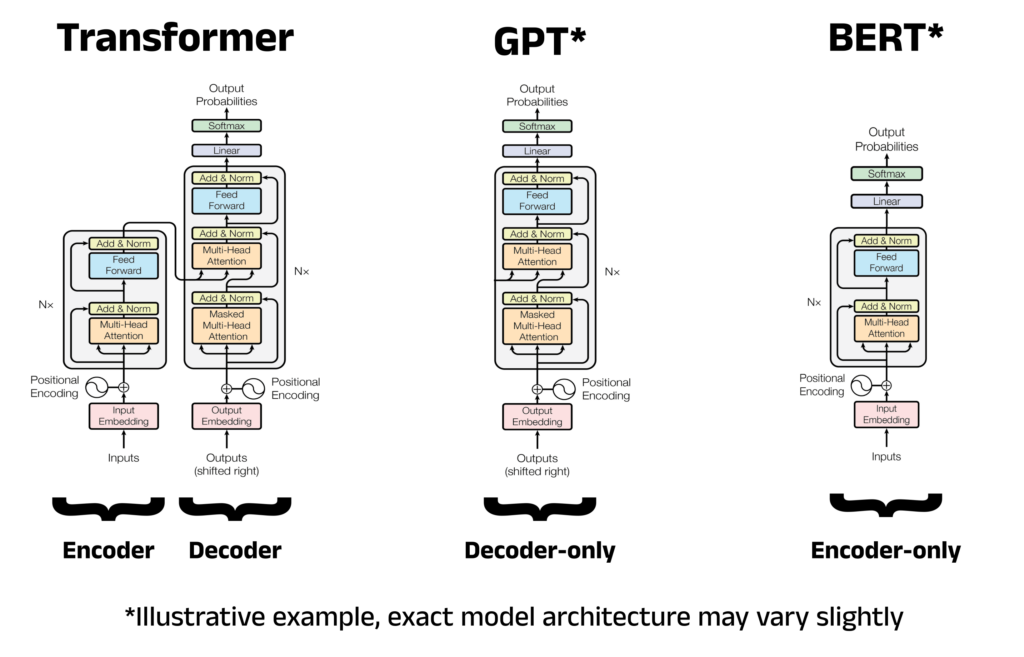

In [4]:
%pip install transformers torch sentencepiece accelerate -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import numpy as np
import pandas as pd

from transformers import (
    BertTokenizer,
    BertModel,
    GPT2Tokenizer,
    GPT2LMHeadModel,
    T5Tokenizer,
    T5ForConditionalGeneration
)

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.12.0+cpu


In [6]:
architectures = pd.DataFrame({
    "Architecture": [
        "Encoder Only",
        "Decoder Only",
        "Encoder Decoder"
    ],
    "Example Models": [
        "BERT",
        "GPT",
        "T5 / BART"
    ],
    "Main Purpose": [
        "Understanding",
        "Generation",
        "Input → Output Tasks"
    ]
})

architectures

,Architecture,Example Models,Main Purpose
0,Encoder Only,BERT,Understanding
1,Decoder Only,GPT,Generation
2,Encoder Decoder,T5 / BART,Input → Output Tasks


# Load Models

In [7]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")

t5_tokenizer = T5Tokenizer.from_pretrained("t5-small")
t5_model = T5ForConditionalGeneration.from_pretrained("t5-small")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1285.89it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\lenevo\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficie

# BERT Model

BERT (Bidirectional Encoder Representations from Transformers) is a natural language processing model developed by Google that understands the context of words in a sentence by analyzing text in both directions. It is widely used to improve language understanding tasks with high accuracy.
- Uses a transformer-based encoder architecture
- Processes text bidirectionally (left and right context)
- Captures contextual relationships between words
- Designed for language understanding tasks like classification, question answering, and Named Entity Recognition (NER)

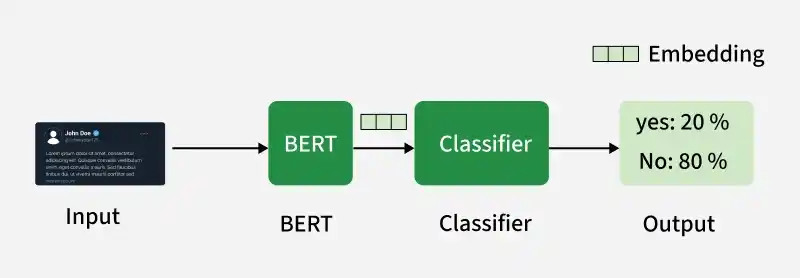

## BERT Tokenization

In [9]:
sentence = "I love Natural Language Processing and AI"

tokens = bert_tokenizer.tokenize(sentence)

print(tokens)

['i', 'love', 'natural', 'language', 'processing', 'and', 'ai']


BERT uses WordPiece tokenization.
Unknown words are broken into subwords.

# GPT model

Generative Pre trained Transformer (GPT) is a language model that understands and generates human like text. It learns patterns and relationships between words from large data and can perform multiple language tasks using a single model.

- Text Understanding: GPT can read and understand human language.
- Text Generation: It can generate meaningful and natural sounding text.
- Learning from Data: It is trained on large datasets to learn language patterns.
- Multiple Tasks: It can write, summarize, answer questions and even help in coding.
- Context Awareness: It understands how words relate to each other to give relevant responses.

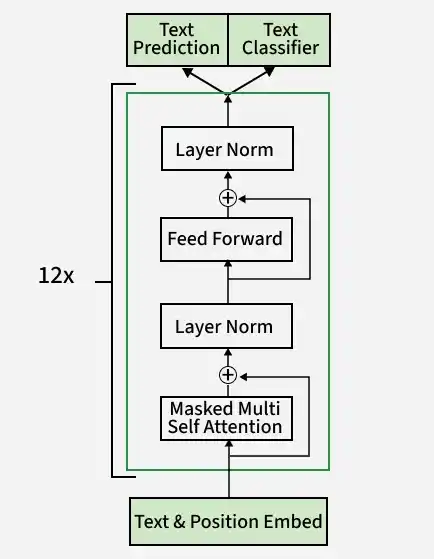

## GPT Tokenization

In [10]:
tokens =  gpt_tokenizer.tokenize(sentence)

print(tokens)

['I', 'Ġlove', 'ĠNatural', 'ĠLanguage', 'ĠProcessing', 'Ġand', 'ĠAI']


GPT uses Byte Pair Encoding (BPE).

## BERT embeddings

In [11]:
inputs = bert_tokenizer(
    sentence,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = bert_model(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([1, 9, 768])


Each token receives a contextual embedding.

## Inspect BERT Token Embeddings

In [12]:
tokens = bert_tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

for token, vector in zip(tokens, outputs.last_hidden_state[0]):
    print(token, vector.shape)

[CLS] torch.Size([768])
i torch.Size([768])
love torch.Size([768])
natural torch.Size([768])
language torch.Size([768])
processing torch.Size([768])
and torch.Size([768])
ai torch.Size([768])
[SEP] torch.Size([768])


#### Why BERT is Encoder-Only

Visualize Full Attention

In [13]:
length = 6

mask = np.ones((length, length))

print(mask)

[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]


Every token sees every other token.
Bidirectional attention.

#### Visualize GPT Causal Mask

In [15]:
length = 6

mask = np.tril(np.ones((length, length)))

print(mask)

[[1. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1.]]


Future tokens are hidden.
GPT can only see the past.

### Generate text with GPT

In [16]:
prompt = "Artificial Intelligence is"

inputs = gpt_tokenizer(
    prompt,
    return_tensors="pt"
)

output = gpt_model.generate(
    **inputs,
    max_length=40
)

generated = gpt_tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print(generated)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Artificial Intelligence is a new field of research that has been gaining traction in recent years. It is a field that has been growing in popularity since the early 1990s.

The field is called


## Next Token Prediction

In [20]:
prompt = "I am a college"

inputs = gpt_tokenizer(
    prompt,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = gpt_model(**inputs)

next_token_logits = outputs.logits[:, -1, :]

next_token = torch.argmax(
    next_token_logits,
    dim=-1
)

print(
    gpt_tokenizer.decode(next_token)
)

 student


In [21]:
prompt = "My name is"

inputs = gpt_tokenizer(
    prompt,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = gpt_model(**inputs)

next_token_logits = outputs.logits[:, -1, :]

next_token = torch.argmax(
    next_token_logits,
    dim=-1
)

print(
    gpt_tokenizer.decode(next_token)
)

 John


This demonstrates GPT's core objective.

# Transformer (T5)

The T5 (Text-to-Text Transfer Transformer) is a versatile, encoder-decoder language model developed by Google.

Instead of using task-specific heads, T5 models use a standard Transformer architecture to apply a task prefix (e.g., "translate English to German:") to the input.
- Encoder: Reads and bidirectionally processes the entire input sequence, fully understanding the context of every word.
- Decoder: Generates the target text step-by-step, looking back at both the encoded input and the words it has already produced.

## BERT Masked Language Modeling

In [29]:
from transformers import BertForMaskedLM

mlm_model = BertForMaskedLM.from_pretrained(
    "bert-base-uncased"
)

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 1234.55it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### Fill mask example

In [31]:
text = "Kathmandu is the [MASK] of Nepal."

inputs = bert_tokenizer(
    text,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = mlm_model(**inputs)

mask_index = (
    inputs.input_ids[0]
    == bert_tokenizer.mask_token_id
).nonzero(as_tuple=True)[0]

predicted_token_id = torch.argmax(
    outputs.logits[0, mask_index],
    dim=-1
)

predicted_word = bert_tokenizer.decode(
    predicted_token_id
)

print(predicted_word)

capital


## Encoder-Decoder Example (T5)

In [34]:
text = "translate English to German: I love machine learning"

inputs = t5_tokenizer(
    text,
    return_tensors="pt"
)

outputs = t5_model.generate(
    inputs.input_ids,
    max_length=50
)

print(
    t5_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )
)

Ich liebe das Maschinenlernen


Encoder reads input.
Decoder generates output.

## Summarization with T5

In [35]:
text = """
summarize:
Transformers are deep learning models
that use attention mechanisms to process
sequences efficiently and achieve
state-of-the-art NLP performance.
"""

inputs = t5_tokenizer(
    text,
    return_tensors="pt",
    max_length=512,
    truncation=True
)

summary_ids = t5_model.generate(
    inputs.input_ids,
    max_length=30
)

print(
    t5_tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )
)

Transformers are deep learning models that use attention mechanisms to process sequences efficiently.


In [36]:
comparison = pd.DataFrame({
    "Model":["BERT","GPT","T5"],
    "Training Objective":[
        "Masked Language Modeling",
        "Next Token Prediction",
        "Seq2Seq Learning"
    ],
    "Attention":[
        "Bidirectional",
        "Causal",
        "Encoder + Decoder"
    ]
})

comparison

,Model,Training Objective,Attention
0,BERT,Masked Language Modeling,Bidirectional
1,GPT,Next Token Prediction,Causal
2,T5,Seq2Seq Learning,Encoder + Decoder


In [37]:
use_cases = pd.DataFrame({
    "Task":[
        "Sentiment Analysis",
        "Question Answering",
        "Chatbot",
        "Story Generation",
        "Translation",
        "Summarization"
    ],
    "Best Model":[
        "BERT",
        "BERT",
        "GPT",
        "GPT",
        "T5",
        "T5"
    ]
})

use_cases

,Task,Best Model
0,Sentiment Analysis,BERT
1,Question Answering,BERT
2,Chatbot,GPT
3,Story Generation,GPT
4,Translation,T5
5,Summarization,T5


BERT
- Encoder Only
- Bidirectional Attention
- Understanding

GPT:
- Decoder Only
- Causal Attention
- Generation

T5:
- Encoder Decoder
- Seq2Seq
- Translation/Summarization

# Key Learnings

1. BERT uses encoder-only architecture.
2. GPT uses decoder-only architecture.
3. T5 uses encoder-decoder architecture.
4. BERT uses Masked Language Modeling.
5. GPT uses Next Token Prediction.
6. T5 converts one sequence into another.
7. Encoder attention is bidirectional.
8. Decoder attention is causal.
9. Cross-attention connects encoder and decoder.
10. Different transformer architectures are optimized for different NLP tasks.